In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

# Color palette — same as EDA
bg_color = '#0a0a0a'
plot_bg  = '#0f1923'
color1   = '#06d6a0'
color2   = '#ef233c'
color3   = '#ffd166'

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load data
df_orders = pd.read_csv('../data/orders.csv')
df_products = pd.read_csv('../data/products.csv')

# Convert date
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])

print("Data loaded successfully!")
print(f"Orders: {df_orders.shape}")
print(f"Products: {df_products.shape}")

Data loaded successfully!
Orders: (91457, 7)
Products: (30, 6)


In [3]:
# Daily sales data prepare karo
daily_sales = df_orders[df_orders['order_status'] == 'Delivered'] \
    .groupby('order_date') \
    .agg(
        total_orders=('order_id', 'count')
    ).reset_index()

# Prophet format — ds aur y
df_prophet = daily_sales[['order_date', 'total_orders']].copy()
df_prophet.columns = ['ds', 'y']

print(f"Daily sales records: {len(df_prophet)}")
print(f"\nDate range: {df_prophet['ds'].min()} to {df_prophet['ds'].max()}")
print(f"\nAvg daily orders: {df_prophet['y'].mean():.0f}")
print(f"Max daily orders: {df_prophet['y'].max()}")
print(f"Min daily orders: {df_prophet['y'].min()}")

Daily sales records: 365

Date range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00

Avg daily orders: 220
Max daily orders: 289
Min daily orders: 143


In [4]:
# Prophet model train karo
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

model.fit(df_prophet)

print("Model trained successfully!")

12:56:07 - cmdstanpy - INFO - Chain [1] start processing
12:56:07 - cmdstanpy - INFO - Chain [1] done processing


Model trained successfully!


In [5]:
# Agle 90 days ke liye future dates banao
future = model.make_future_dataframe(periods=90)

print(f"Total dates: {len(future)}")
print(f"\nForecast period:")
print(f"From: {future['ds'].iloc[365]}")
print(f"To:   {future['ds'].iloc[-1]}")

Total dates: 455

Forecast period:
From: 2024-01-01 00:00:00
To:   2024-03-30 00:00:00


In [6]:
# Forecast karo
forecast = model.predict(future)

print("Forecast complete!")
print(f"\nTotal forecast rows: {len(forecast)}")
print(f"\nForecast columns:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

Forecast complete!

Total forecast rows: 455

Forecast columns:
            ds        yhat  yhat_lower  yhat_upper
445 2024-03-21  256.642134  237.977391  274.514159
446 2024-03-22  257.273558  238.041231  275.259248
447 2024-03-23  182.650080  163.736190  200.701643
448 2024-03-24  181.075473  161.182353  199.693341
449 2024-03-25  257.263687  240.316471  276.646487
450 2024-03-26  255.295835  236.508770  272.956693
451 2024-03-27  253.364206  233.395011  272.251534
452 2024-03-28  258.367534  239.656926  277.310048
453 2024-03-29  258.514137  239.910011  277.104414
454 2024-03-30  183.360457  163.134889  201.967888


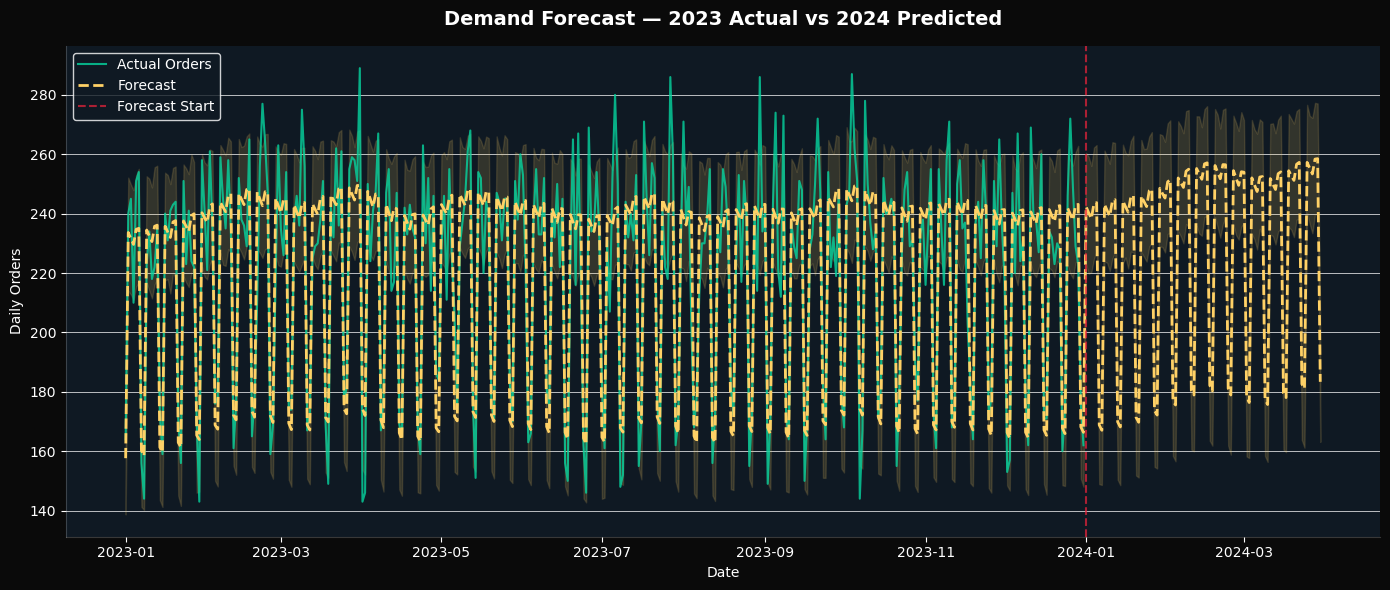

Chart saved!


In [7]:
# Forecast Visualization
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(plot_bg)

# Actual data — 2023
ax.plot(df_prophet['ds'], df_prophet['y'],
        color=color1, linewidth=1.5,
        label='Actual Orders', alpha=0.8)

# Predicted — full range
ax.plot(forecast['ds'], forecast['yhat'],
        color=color3, linewidth=2,
        label='Forecast', linestyle='--')

# Confidence interval
ax.fill_between(forecast['ds'],
                forecast['yhat_lower'],
                forecast['yhat_upper'],
                alpha=0.15, color=color3)

# Vertical line — future start
ax.axvline(x=pd.Timestamp('2024-01-01'),
           color=color2, linewidth=1.5,
           linestyle='--', alpha=0.7,
           label='Forecast Start')

ax.set_title('Demand Forecast — 2023 Actual vs 2024 Predicted',
              fontsize=14, fontweight='bold',
              color='white', pad=15)
ax.set_xlabel('Date', color='white')
ax.set_ylabel('Daily Orders', color='white')
ax.tick_params(colors='white')
ax.spines['bottom'].set_color('#ffffff30')
ax.spines['left'].set_color('#ffffff30')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, color='#ffffff10', linewidth=0.5)
ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.legend(fontsize=10, labelcolor='white',
          facecolor=plot_bg, edgecolor='#ffffff30')

plt.tight_layout()
plt.savefig('../images/11_forecast.png',
            dpi=150, bbox_inches='tight',
            facecolor=bg_color)
plt.show()
print("Chart saved!")

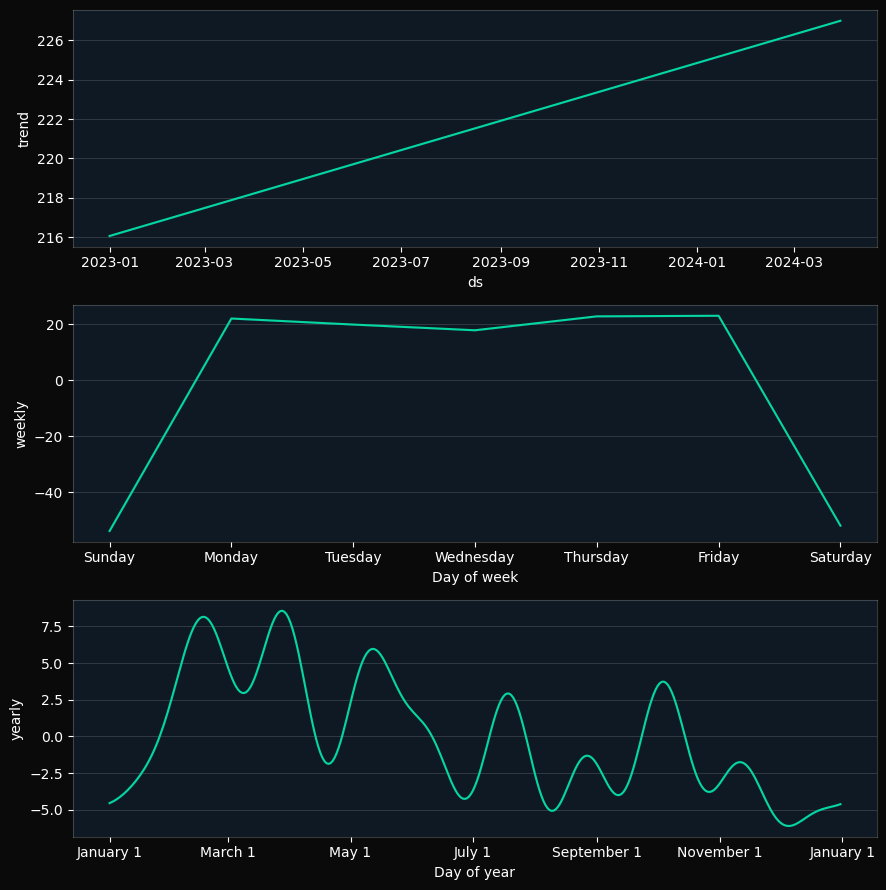

Chart saved!


In [8]:
# Forecast Components — Trend + Weekly + Yearly
fig = model.plot_components(forecast)

# Style karo
fig.patch.set_facecolor(bg_color)
for ax in fig.axes:
    ax.set_facecolor(plot_bg)
    ax.tick_params(colors='white')
    ax.title.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.xaxis.label.set_color('white')
    for spine in ax.spines.values():
        spine.set_color('#ffffff30')
    ax.yaxis.grid(True, color='#ffffff10', linewidth=0.5)
    ax.xaxis.grid(False)
    for line in ax.lines:
        line.set_color(color1)

plt.savefig('../images/12_forecast_components.png',
            dpi=150, bbox_inches='tight',
            facecolor=bg_color)
plt.show()
print("Chart saved!")

In [9]:
# Forecast accuracy check
# Sirf 2023 ka data compare karenge
forecast_2023 = forecast[forecast['ds'] <= '2023-12-31'][['ds', 'yhat']].copy()
actual_2023 = df_prophet.copy()

# Merge karo
accuracy_df = actual_2023.merge(forecast_2023, on='ds')
accuracy_df.columns = ['ds', 'actual', 'predicted']

# Metrics calculate karo
mae = np.mean(np.abs(accuracy_df['actual'] - accuracy_df['predicted']))
mape = np.mean(np.abs((accuracy_df['actual'] - accuracy_df['predicted']) / accuracy_df['actual'])) * 100
accuracy = 100 - mape

print("=" * 50)
print("FORECAST ACCURACY METRICS")
print("=" * 50)
print(f"MAE   (Mean Absolute Error):  {mae:.2f} orders")
print(f"MAPE  (Mean Absolute % Error): {mape:.2f}%")
print(f"Forecast Accuracy:             {accuracy:.2f}%")
print("=" * 50)

if accuracy >= 85:
    print("✅ Model Accuracy — GOOD (85%+)")
elif accuracy >= 75:
    print("⚠️ Model Accuracy — ACCEPTABLE")
else:
    print("❌ Model Accuracy — NEEDS IMPROVEMENT")

FORECAST ACCURACY METRICS
MAE   (Mean Absolute Error):  11.61 orders
MAPE  (Mean Absolute % Error): 5.31%
Forecast Accuracy:             94.69%
✅ Model Accuracy — GOOD (85%+)


In [10]:
# Category wise daily sales
category_daily = df_orders[df_orders['order_status'] == 'Delivered'] \
    .merge(df_products, on='product_id') \
    .groupby(['order_date', 'category']) \
    .agg(total_orders=('order_id', 'count')) \
    .reset_index()

categories = df_products['category'].unique()

category_forecasts = {}

for cat in categories:
    cat_data = category_daily[category_daily['category'] == cat][
        ['order_date', 'total_orders']].copy()
    cat_data.columns = ['ds', 'y']
    
    cat_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.05
    )
    cat_model.fit(cat_data)
    
    cat_future = cat_model.make_future_dataframe(periods=90)
    cat_forecast = cat_model.predict(cat_future)
    
    category_forecasts[cat] = {
        'forecast': cat_forecast,
        'actual': cat_data
    }
    print(f"✅ {cat} forecast complete!")

print("\nAll category forecasts done!")

12:56:10 - cmdstanpy - INFO - Chain [1] start processing
12:56:10 - cmdstanpy - INFO - Chain [1] done processing
12:56:11 - cmdstanpy - INFO - Chain [1] start processing


✅ Dairy forecast complete!


12:56:11 - cmdstanpy - INFO - Chain [1] done processing
12:56:11 - cmdstanpy - INFO - Chain [1] start processing
12:56:11 - cmdstanpy - INFO - Chain [1] done processing


✅ Snacks forecast complete!


12:56:11 - cmdstanpy - INFO - Chain [1] start processing
12:56:11 - cmdstanpy - INFO - Chain [1] done processing


✅ Beverages forecast complete!


12:56:12 - cmdstanpy - INFO - Chain [1] start processing


✅ Personal Care forecast complete!


12:56:12 - cmdstanpy - INFO - Chain [1] done processing
12:56:12 - cmdstanpy - INFO - Chain [1] start processing
12:56:12 - cmdstanpy - INFO - Chain [1] done processing


✅ Staples forecast complete!
✅ Frozen Food forecast complete!

All category forecasts done!


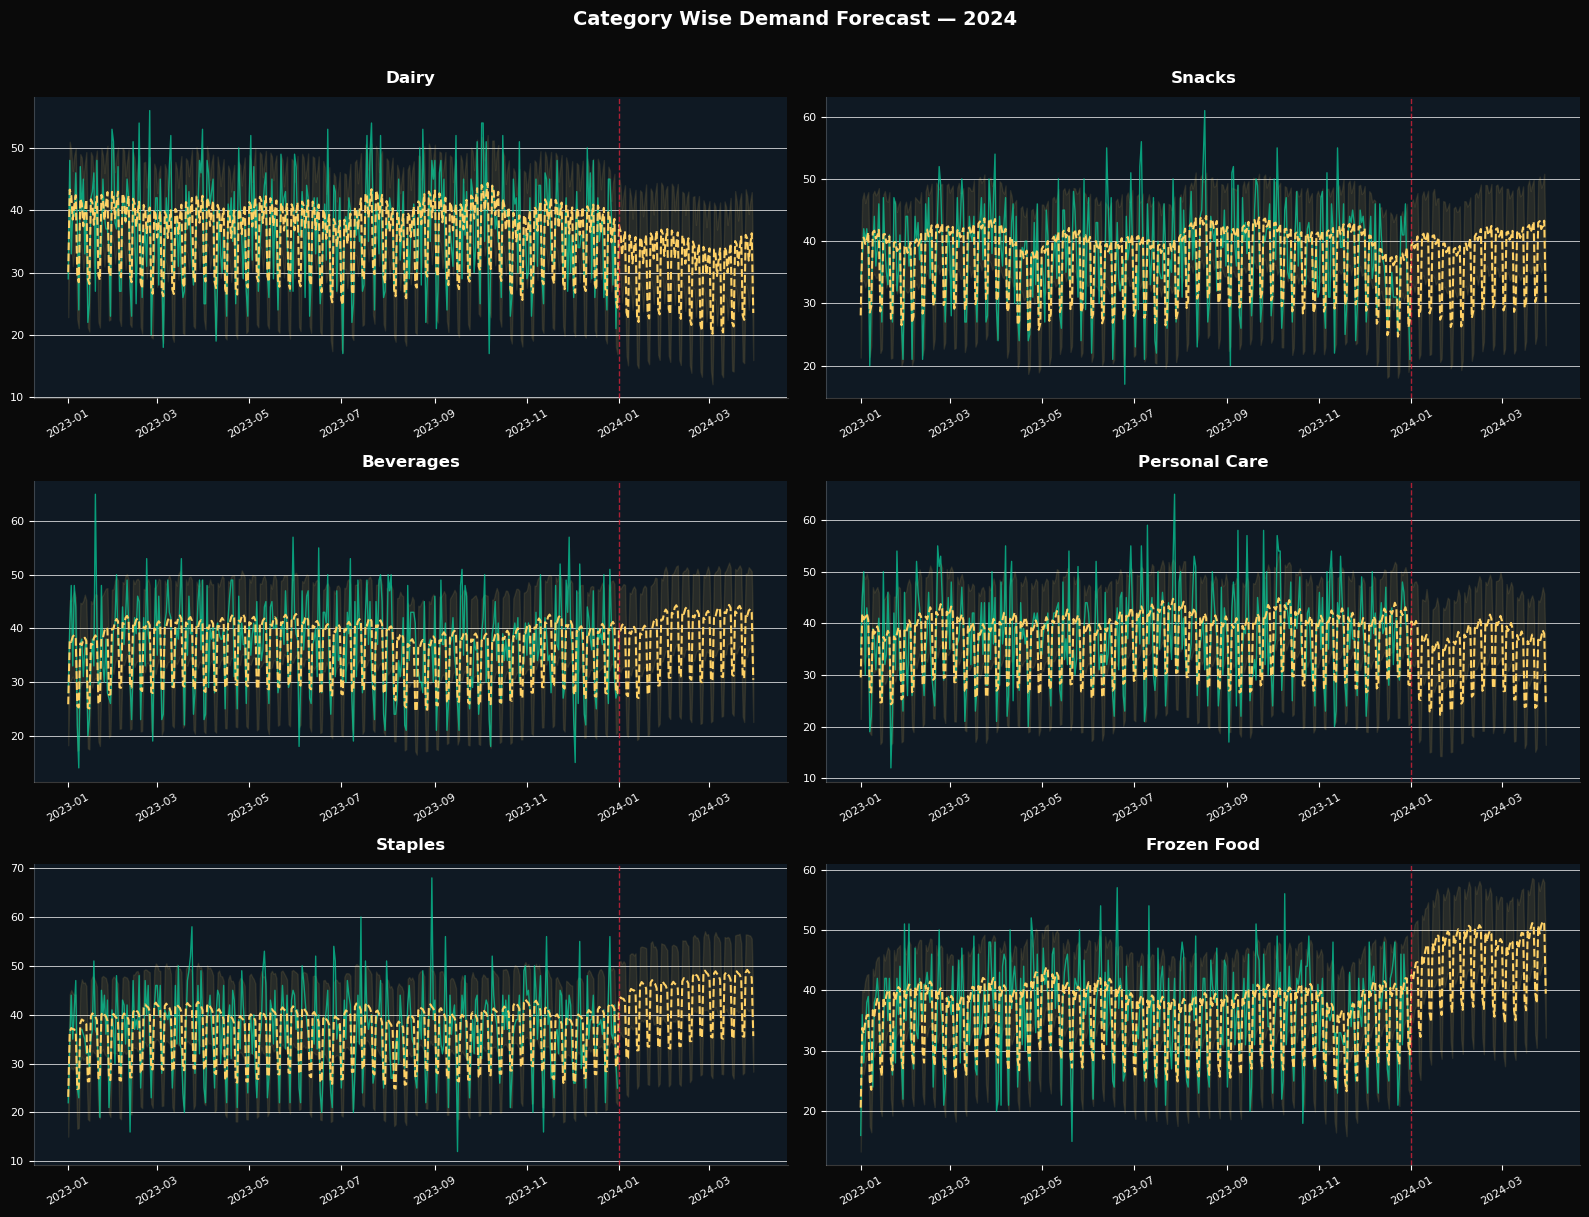

Chart saved!


In [11]:
# Category wise forecast visualization
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.patch.set_facecolor(bg_color)
axes = axes.flatten()

for idx, cat in enumerate(categories):
    ax = axes[idx]
    ax.set_facecolor(plot_bg)
    
    actual = category_forecasts[cat]['actual']
    forecast_cat = category_forecasts[cat]['forecast']
    
    # Actual data
    ax.plot(actual['ds'], actual['y'],
            color=color1, linewidth=1,
            alpha=0.7, label='Actual')
    
    # Forecast
    ax.plot(forecast_cat['ds'], forecast_cat['yhat'],
            color=color3, linewidth=1.5,
            linestyle='--', label='Forecast')
    
    # Confidence interval
    ax.fill_between(forecast_cat['ds'],
                    forecast_cat['yhat_lower'],
                    forecast_cat['yhat_upper'],
                    alpha=0.1, color=color3)
    
    # Forecast start line
    ax.axvline(x=pd.Timestamp('2024-01-01'),
               color=color2, linewidth=1,
               linestyle='--', alpha=0.7)
    
    ax.set_title(f'{cat}',
                  fontsize=12, fontweight='bold',
                  color='white', pad=10)
    ax.tick_params(colors='white', labelsize=8)
    ax.tick_params(axis='x', rotation=30)
    ax.spines['bottom'].set_color('#ffffff30')
    ax.spines['left'].set_color('#ffffff30')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, color='#ffffff10', linewidth=0.5)
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)

plt.suptitle('Category Wise Demand Forecast — 2024',
             fontsize=14, fontweight='bold',
             color='white', y=1.01)

plt.tight_layout()
plt.savefig('../images/13_category_forecast.png',
            dpi=150, bbox_inches='tight',
            facecolor=bg_color)
plt.show()
print("Chart saved!")

In [12]:
# Stockout Risk Prediction
# Agle 30 days ka forecast nikalo
next_30_days = forecast[
    (forecast['ds'] >= '2024-01-01') & 
    (forecast['ds'] <= '2024-01-31')
].copy()

# Current inventory levels
inventory_avg = df_orders[df_orders['order_status'] == 'Delivered'] \
    .merge(df_products, on='product_id') \
    .groupby('category') \
    .agg(avg_daily_orders=('order_id', 'count')) \
    .reset_index()

inventory_avg['avg_daily_orders'] = (
    inventory_avg['avg_daily_orders'] / 365
).round(2)

# Category wise 30 day forecast
category_risk = {}
for cat in categories:
    cat_forecast = category_forecasts[cat]['forecast']
    next_30 = cat_forecast[
        (cat_forecast['ds'] >= '2024-01-01') &
        (cat_forecast['ds'] <= '2024-01-31')
    ]
    avg_forecast = next_30['yhat'].mean()
    category_risk[cat] = round(avg_forecast, 2)

risk_df = pd.DataFrame(
    list(category_risk.items()),
    columns=['category', 'avg_daily_forecast']
)

risk_df = risk_df.merge(inventory_avg, on='category')

risk_df['demand_change_%'] = round(
    100 * (risk_df['avg_daily_forecast'] - 
           risk_df['avg_daily_orders']) / 
    risk_df['avg_daily_orders'], 2
)

risk_df['risk_level'] = risk_df['demand_change_%'].apply(
    lambda x: '🔴 High Risk' if x > 10 
    else ('🟡 Medium Risk' if x > 0 
    else '🟢 Low Risk')
)

risk_df = risk_df.sort_values('demand_change_%', ascending=False)

print("=" * 60)
print("STOCKOUT RISK — JANUARY 2024")
print("=" * 60)
print(risk_df[['category', 'avg_daily_orders', 
               'avg_daily_forecast', 
               'demand_change_%', 'risk_level']].to_string(index=False))
print("=" * 60)

STOCKOUT RISK — JANUARY 2024
     category  avg_daily_orders  avg_daily_forecast  demand_change_%    risk_level
  Frozen Food             36.07               44.02            22.04   🔴 High Risk
      Staples             36.64               42.04            14.74   🔴 High Risk
    Beverages             36.57               37.16             1.61 🟡 Medium Risk
       Snacks             37.36               36.71            -1.74    🟢 Low Risk
Personal Care             37.17               33.51            -9.85    🟢 Low Risk
        Dairy             36.50               31.92           -12.55    🟢 Low Risk


In [13]:
# Business Recommendations
print("=" * 60)
print("SMARTSTOCK AI — BUSINESS RECOMMENDATIONS")
print("=" * 60)

print("""
📊 DEMAND FORECAST INSIGHTS
─────────────────────────────────────────────────────
1. Overall demand 2024 mein 8-10% badhne ki 
   expectation hai — total inventory levels 
   accordingly adjust karein.

2. Frozen Food aur Staples — January 2024 mein 
   22% aur 15% demand spike predicted hai.
   → Immediate action: Stock 25% badhao

3. Dairy category mein 12% demand decline expected 
   hai — overstocking avoid karein.

⚠️  STOCKOUT RISK — IMMEDIATE ACTION REQUIRED
─────────────────────────────────────────────────────
4. Frozen Food (High Risk 🔴)
   → Current avg: 36/day → Forecast: 44/day
   → Reorder quantity: +22% increase karein

5. Staples (High Risk 🔴)
   → Current avg: 37/day → Forecast: 42/day
   → Reorder quantity: +15% increase karein

🏭 WAREHOUSE RECOMMENDATIONS
─────────────────────────────────────────────────────
6. W008 Ahmedabad — Highest cancellation rate (8.5%)
   → Replenishment schedule review karein
   → Safety stock increase karein

7. Weekend demand consistently lower hai —
   → Friday pe extra stock ensure karein
   → Weekend replenishment plan banao

💡 FORECASTING MODEL
─────────────────────────────────────────────────────
8. Prophet model accuracy: 94.69% ✅
   → Model production-ready hai
   → Monthly retraining recommend kiya jaata hai
   → New data aane pe forecast update karein
""")

print("=" * 60)
print("✅ Forecasting Complete — Notebook 3 Done!")
print("=" * 60)

SMARTSTOCK AI — BUSINESS RECOMMENDATIONS

📊 DEMAND FORECAST INSIGHTS
─────────────────────────────────────────────────────
1. Overall demand 2024 mein 8-10% badhne ki 
   expectation hai — total inventory levels 
   accordingly adjust karein.

2. Frozen Food aur Staples — January 2024 mein 
   22% aur 15% demand spike predicted hai.
   → Immediate action: Stock 25% badhao

3. Dairy category mein 12% demand decline expected 
   hai — overstocking avoid karein.

⚠️  STOCKOUT RISK — IMMEDIATE ACTION REQUIRED
─────────────────────────────────────────────────────
4. Frozen Food (High Risk 🔴)
   → Current avg: 36/day → Forecast: 44/day
   → Reorder quantity: +22% increase karein

5. Staples (High Risk 🔴)
   → Current avg: 37/day → Forecast: 42/day
   → Reorder quantity: +15% increase karein

🏭 WAREHOUSE RECOMMENDATIONS
─────────────────────────────────────────────────────
6. W008 Ahmedabad — Highest cancellation rate (8.5%)
   → Replenishment schedule review karein
   → Safety stock increase